In [25]:
# ESSENTIAL LIBRARIES FOR BUSINESS ANALYTICS
# ============================================

# Data Manipulation & Analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns

# Statistical Analysis

# Utility

# Suppress warnings for cleaner output
import warnings
from scipy import stats
import plotly
warnings.filterwarnings('ignore')

# ============================================
# PANDAS CONFIGURATION
# ============================================

# Display settings
pd.set_option('display.max_columns', 100)        # Show all columns
pd.set_option('display.max_rows', 100)           # Show more rows
pd.set_option('display.width', 1000)             # Wider display
pd.set_option('display.precision', 2)            # 2 decimal places
pd.set_option('display.float_format', '{:,.2f}'.format)  # Format numbers
pd.set_option('display.max_colwidth', 50)        # Column width
pd.set_option('display.max_info_columns', 100)   # More info columns
pd.set_option('display.max_info_rows', 100)      # More info rows

# Memory optimization
pd.set_option('mode.chained_assignment', 'warn')  # Warn on chain assignment

# ============================================
# VISUALIZATION CONFIGURATION
# ============================================

# Matplotlib Configuration
plt.rcParams.update({
    # Figure Settings
    'figure.figsize': (12, 6),           # Default figure size
    'figure.dpi': 100,                   # Screen resolution
    'figure.facecolor': 'white',         # Figure background
    'figure.edgecolor': 'white',         # Figure border
    
    # Font & Text
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Helvetica'],
    'font.size': 11,                     # Base font size
    'axes.titlesize': 14,                # Title size
    'axes.labelsize': 12,                # Label size
    'xtick.labelsize': 10,               # X-tick size
    'ytick.labelsize': 10,               # Y-tick size
    
    # Axes Styling
    'axes.spines.top': False,            # Remove top spine
    'axes.spines.right': False,          # Remove right spine
    'axes.grid': True,                   # Show grid
    'grid.alpha': 0.3,                   # Grid transparency
    'grid.linestyle': '--',              # Grid style
    'grid.color': '#CCCCCC',             # Grid color
    
    # Colors
    'axes.prop_cycle': plt.cycler('color', [
        '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
        '#3B60E4', '#A34D9F', '#20A39E', '#EF5B5B', '#FFBA08'
    ]),
    
    # Legend
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    'legend.edgecolor': '#CCCCCC',
    'legend.fontsize': 10,
    
    # Save settings
    'savefig.dpi': 300,                  # High-res saving
    'savefig.bbox': 'tight',             # Tight layout
    'savefig.facecolor': 'white',
    'savefig.format': 'png'
})

# Seaborn Configuration
sns.set_theme(style="whitegrid")  # Base theme
sns.set_palette("husl")           # Color palette

# Custom color palettes for business contexts
BUSINESS_PALETTES = {
    'primary': ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B'],
    'corporate': ['#003f5c', '#58508d', '#bc5090', '#ff6361', '#ffa600'],
    'performance': ['#2ecc71', '#e74c3c', '#f39c12', '#3498db', '#9b59b6'],
    'kpi': ['#27ae60', '#c0392b', '#f39c12', '#2980b9', '#8e44ad'],
    'gradient_green': sns.light_palette("#2ecc71", as_cmap=True),
    'gradient_red': sns.light_palette("#e74c3c", as_cmap=True),
    'gradient_blue': sns.light_palette("#3498db", as_cmap=True)
}

# ============================================
# BUSINESS INSIGHTS FUNCTIONS
# ============================================

class BusinessInsights:
    """Quick statistical and business insight functions."""
    
    @staticmethod
    def describe_business(df, target_col=None):
        """Generate business-focused data description."""
        desc = df.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
        
        # Add business metrics
        desc.loc['skewness'] = df.skew()
        desc.loc['kurtosis'] = df.kurtosis()
        desc.loc['missing'] = df.isnull().sum()
        desc.loc['missing_pct'] = (df.isnull().sum() / len(df)) * 100
        desc.loc['unique_values'] = df.nunique()
        
        return desc
    
    @staticmethod
    def correlation_insights(df, target, top_n=10):
        """Get top correlations with target variable."""
        correlations = df.corr()[target].sort_values(ascending=False)
        
        print("\nTOP CORRELATIONS WITH '{}'".format(target))
        print("="*50)
        
        for col, corr in correlations.items():
            if col == target:
                continue
            strength = "Strong" if abs(corr) > 0.7 else "Medium" if abs(corr) > 0.5 else "Weak"
            direction = "positive" if corr > 0 else "negative"
            print(f"{col}: {corr:.3f} ({direction}, {strength})")
        
        return correlations
    
    @staticmethod
    def value_ranges(df, cols=None):
        """Show min, max, and range for business understanding."""
        if cols is None:
            cols = df.select_dtypes(include=[np.number]).columns
        
        ranges = pd.DataFrame({
            'Min': df[cols].min(),
            'Q25': df[cols].quantile(0.25),
            'Median': df[cols].median(),
            'Q75': df[cols].quantile(0.75),
            'Max': df[cols].max(),
            'Range': df[cols].max() - df[cols].min(),
            'IQR': df[cols].quantile(0.75) - df[cols].quantile(0.25)
        })
        
        return ranges.round(2)

# ============================================
# PROFESSIONAL PLOTTING FUNCTIONS
# ============================================

def setup_plot_style(figsize=(12, 6), title=None, xlabel=None, ylabel=None):
    """Quick professional plot setup."""
    fig, ax = plt.subplots(figsize=figsize)
    
    if title:
        ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=12, fontweight='500')
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=12, fontweight='500')
    
    # Professional styling
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    return fig, ax

def save_plot(fig, filename, folder="visualizations", formats=['png', 'pdf']):
    """Save plot in multiple formats."""
    Path(folder).mkdir(parents=True, exist_ok=True)
    
    for fmt in formats:
        filepath = Path(folder) / f"{filename}.{fmt}"
        fig.savefig(filepath, dpi=300, bbox_inches='tight', facecolor='white')
    
    print(f"Plot saved: {folder}/{filename}.{formats}")
    plt.show()

# ============================================
# QUICK EDA FUNCTION
# ============================================

def quick_business_eda(df, target_col=None):
    """Complete quick EDA for business understanding."""
    bi = BusinessInsights()
    
    print("="*60)
    print("BUSINESS DATA OVERVIEW")
    print("="*60)
    print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print(f"Date Range: {df.index.min()} to {df.index.max()}" if hasattr(df.index, 'min') else "")
    
    print("\n" + "="*60)
    print("DATA TYPES")
    print("="*60)
    print(df.dtypes.value_counts())
    
    print("\n" + "="*60)
    print("MISSING VALUES (>0%)")
    print("="*60)
    missing = (df.isnull().sum() / len(df) * 100)
    missing = missing[missing > 0].sort_values(ascending=False)
    if len(missing) > 0:
        print(missing)
    else:
        print("No missing values!")
    
    if target_col and target_col in df.columns:
        print("\n" + "="*60)
        print(f"TARGET VARIABLE: {target_col}")
        print("="*60)
        print(df[target_col].describe())
        bi.correlation_insights(df, target_col)
    
    print("\n" + "="*60)
    print("NUMERICAL FEATURES SUMMARY")
    print("="*60)
    display(bi.describe_business(df.select_dtypes(include=[np.number])))

# ============================================
# INITIALIZATION CHECK
# ============================================

def check_environment():
    """Verify environment setup."""
    print("Environment Ready!")
    print(f"• Pandas {pd.__version__}")
    print(f"• NumPy {np.__version__}")
    print(f"• Matplotlib {plt.matplotlib.__version__}")
    print(f"• Seaborn {sns.__version__}")
    print(f"• Plotly {plotly.__version__}")
    print(f"• Scipy {stats.__version__ if hasattr(stats, '__version__') else 'Installed'}")
    print("\nColor palettes available: BUSINESS_PALETTES")
    print("Business tools loaded: BusinessInsights()")

# Run environment check
check_environment()
def check_environment():
    """Verify environment setup."""

    print(" Environment Ready!")
    print(f"• Pandas {pd.__version__}")
    print(f"• NumPy {np.__version__}")
    print(f"• Matplotlib {plt.matplotlib.__version__}")
    print(f"• Seaborn {sns.__version__}")
    print(f"• Plotly {plotly.__version__}")
    print(f"• Scipy {stats.__version__ if hasattr(stats, '__version__') else 'Installed'}")
    print("\n Color palettes available: BUSINESS_PALETTES")
    print(" Business tools loaded: BusinessInsights()")
# Run environment check
check_environment()

Environment Ready!
• Pandas 2.3.1
• NumPy 2.2.6
• Matplotlib 3.10.3
• Seaborn 0.13.2
• Plotly 6.3.0
• Scipy Installed

Color palettes available: BUSINESS_PALETTES
Business tools loaded: BusinessInsights()
 Environment Ready!
• Pandas 2.3.1
• NumPy 2.2.6
• Matplotlib 3.10.3
• Seaborn 0.13.2
• Plotly 6.3.0
• Scipy Installed

 Color palettes available: BUSINESS_PALETTES
 Business tools loaded: BusinessInsights()


In [7]:
def load_curated_data(dataset_name="user_activity"):
    """
    Load curated dataset with automatic path detection.
    """
    from pathlib import Path
    
    # Possible locations
    possible_paths = [
        Path(r"G:\Study\DATA SCINCE\PROJECTS\POTFOLIO\telecom-consumption-intelligence\data\curated") / f"{dataset_name}_curated.parquet",
        Path("data/curated") / f"{dataset_name}_curated.parquet",
        Path("curated") / f"{dataset_name}_curated.parquet",
        Path("../data/curated") / f"{dataset_name}_curated.parquet",
        Path.cwd() / "data" / "curated" / f"{dataset_name}_curated.parquet",
    ]
    
    for path in possible_paths:
        if path.exists():
            df = pd.read_parquet(path)
            print(f" Loaded: {path}")
            print(f"  Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
            return df
    
    # If not found
    raise FileNotFoundError(
        f"Dataset '{dataset_name}_curated.parquet' not found in:\n" +
        "\n".join(f"  • {p}" for p in possible_paths)
    )


df = load_curated_data("user_activity")

 Loaded: G:\Study\DATA SCINCE\PROJECTS\POTFOLIO\telecom-consumption-intelligence\data\curated\user_activity_curated.parquet
  Shape: 10,006 rows × 18 columns


In [8]:
# ============================================
#  DATA SUMMARY
# ============================================

def data_summary(df, name="Dataset"):
    """
    Generate a comprehensive yet quick data summary.
    """
    print("="*70)
    print(f" {name.upper()} SUMMARY")
    print("="*70)
    
    # Basic info
    print(f"\n Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f" Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    # Data types summary
    print(f"\n Data Types:")
    for dtype in df.dtypes.value_counts().index:
        count = df.dtypes.value_counts()[dtype]
        print(f"   • {dtype}: {count} columns")
    
    # Missing values
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_summary = pd.DataFrame({
        'Missing': missing[missing > 0],
        '%': missing_pct[missing > 0]
    })
    
    if len(missing_summary) > 0:
        print(f"\n  Missing Values:")
        print(missing_summary.round(2))
    else:
        print(f"\n No missing values")
    
    # Duplicates
    dupes = df.duplicated().sum()
    if dupes > 0:
        print(f"\n Duplicates: {dupes:,} ({dupes/len(df)*100:.2f}%)")
    else:
        print(f"\n No duplicates")
    
    # Display
    print(f"\n{'='*70}")
    print(" FIRST 5 ROWS")
    print("="*70)
    display(df.head())
    
    print(f"\n{'='*70}")
    print(" DATA INFO")
    print("="*70)
    df.info(verbose=True, show_counts=True)
    
    return None

# Usage
data_summary(df, name="User Activity Curated")


 USER ACTIVITY CURATED SUMMARY

 Shape: 10,006 rows × 18 columns
 Memory: 4.21 MB

 Data Types:
   • float64: 9 columns
   • object: 6 columns
   • int64: 2 columns
   • datetime64[ns]: 1 columns

 No missing values

 No duplicates

 FIRST 5 ROWS


,user_id,measurement_date,hours_streaming,hours_social,hours_messaging,hours_gaming,is_peak_hour_user,is_weekend,age_group,plan_type,device_type,network_type,data_usage_category,streaming_data_gb,social_data_gb,messaging_data_gb,gaming_data_gb,total_data_gb
0,SUB7423388,2026-04-07,0.33,0.66,0.87,0.37,0,1,18-24,Prepaid_Monthly,Mid_Range,4G+,Light,0.54,0.13,0.01,0.06,0.76
1,SUB7550634,2026-04-06,1.07,3.03,0.46,0.04,0,0,45-54,Postpaid_Premium,5G_Device,4G,Moderate,1.21,0.81,0.01,0.00,2.29
2,SUB5304572,2026-03-20,0.54,0.45,0.71,1.25,1,0,25-34,Postpaid_Unlimited,Mid_Range,4G,Light,0.81,0.10,0.01,0.15,1.12
3,SUB3234489,2026-04-14,3.38,1.92,0.00,1.18,1,0,45-54,Postpaid_Unlimited,5G_Device,5G,Power_User,12.06,0.62,0.00,0.13,12.65
4,SUB8204212,2026-03-31,0.25,0.38,0.13,0.47,0,1,25-34,Prepaid_Daily,Premium_Smartphone,4G,Very_Light,0.18,0.09,0.00,0.07,0.50



 DATA INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10006 entries, 0 to 10005
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              10006 non-null  object        
 1   measurement_date     10006 non-null  datetime64[ns]
 2   hours_streaming      10006 non-null  float64       
 3   hours_social         10006 non-null  float64       
 4   hours_messaging      10006 non-null  float64       
 5   hours_gaming         10006 non-null  float64       
 6   is_peak_hour_user    10006 non-null  int64         
 7   is_weekend           10006 non-null  int64         
 8   age_group            10006 non-null  object        
 9   plan_type            10006 non-null  object        
 10  device_type          10006 non-null  object        
 11  network_type         10006 non-null  object        
 12  data_usage_category  10006 non-null  object        
 13  streaming_data_gb  

In [9]:
def quick_train_test_split(df, target_col='total_data_gb', test_size=0.2, random_state=42):
    """
    Simple train/test split for quick EDA.
    """
    from sklearn.model_selection import train_test_split
    
    # Split
    train_data, test_data = train_test_split(
        df, 
        test_size=test_size, 
        random_state=random_state
    )
    
    # Summary
    print(f" Data Split:")
    print(f"   • Training: {len(train_data):,} rows ({len(train_data)/len(df)*100:.1f}%)")
    print(f"   • Test:     {len(test_data):,} rows ({len(test_data)/len(df)*100:.1f}%)")
    
    return train_data, test_data

# Usage
train_data, test_data = quick_train_test_split(df)

 Data Split:
   • Training: 8,004 rows (80.0%)
   • Test:     2,002 rows (20.0%)


OUR DATA IS READY FOR EDA

NOW LETS EXPLORE OUR TARGET 

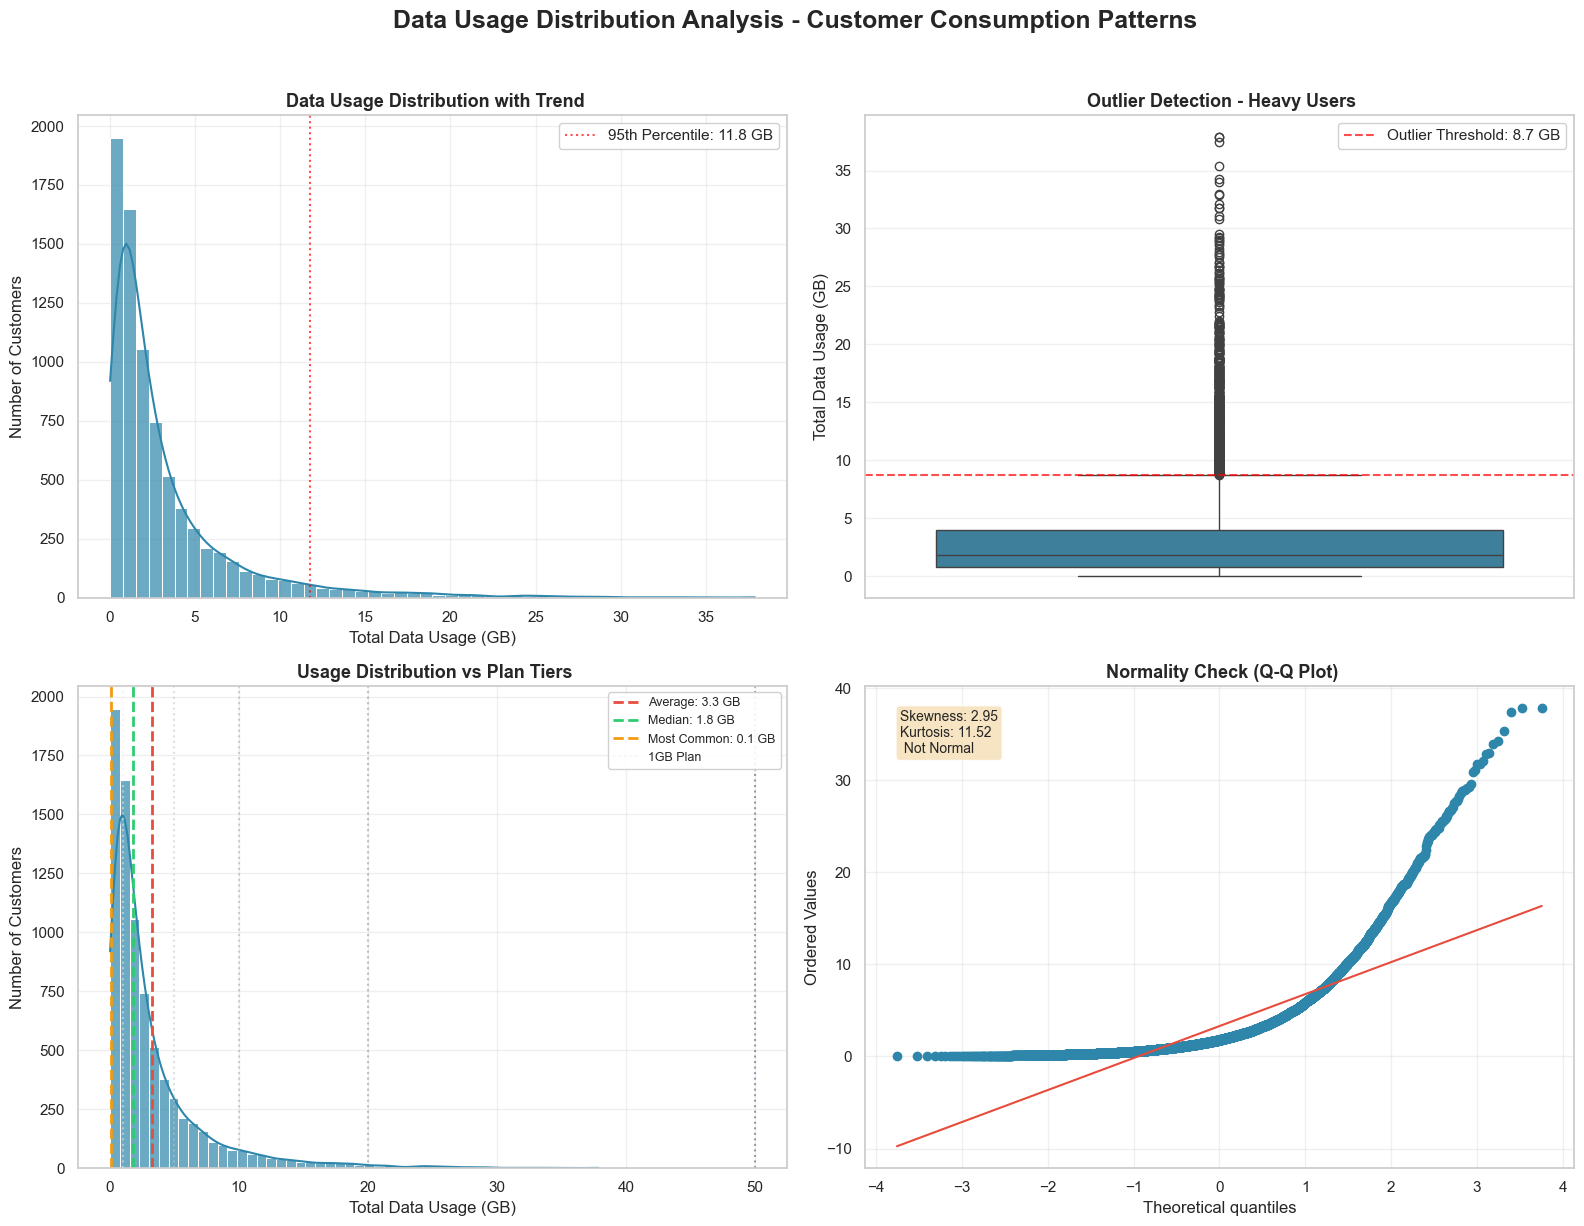

 BUSINESS INSIGHTS - DATA USAGE DISTRIBUTION
• Average Usage: 3.3 GB/customer
• Median Usage: 1.8 GB/customer
• Heavy Users (>95th percentile): 401 customers
• Outliers Detected: 698 customers
• Distribution Shape: Right-Skewed


In [16]:
# ============================================
# TELECOM DATA USAGE DISTRIBUTION ANALYSIS
# ============================================



fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(' Data Usage Distribution Analysis - Customer Consumption Patterns', 
             fontsize=18, fontweight='bold', y=1.02)

# Color scheme for telecom
TELECOM_COLOR = '#2E86AB'
TELECOM_PALETTE = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

# 1. Distribution with KDE
# ensure target_column is the column name (string), not a Series
target_column = 'total_data_gb'
target_series = train_data[target_column]

sns.histplot(target_series, bins=50, kde=True, 
             color=TELECOM_COLOR, alpha=0.7, ax=axes[0,0])
axes[0,0].set_title(" Data Usage Distribution with Trend", fontsize=13, fontweight='bold')
axes[0,0].set_xlabel("Total Data Usage (GB)")
axes[0,0].set_ylabel("Number of Customers")
# Add annotation for business context
p95 = train_data[target_column].quantile(0.95)
axes[0,0].axvline(p95, color='red', linestyle=':', alpha=0.7, 
                  label=f'95th Percentile: {p95:.1f} GB')
axes[0,0].legend()

# 2. Box Plot for Outlier Detection
sns.boxplot(y=train_data[target_column], color=TELECOM_COLOR, ax=axes[0,1])
axes[0,1].set_title(" Outlier Detection - Heavy Users", fontsize=13, fontweight='bold')
axes[0,1].set_ylabel("Total Data Usage (GB)")
# Add business insights
q1 = train_data[target_column].quantile(0.25)
q3 = train_data[target_column].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
axes[0,1].axhline(y=upper_bound, color='red', linestyle='--', alpha=0.7, 
                  label=f'Outlier Threshold: {upper_bound:.1f} GB')
axes[0,1].legend()

# 3. Distribution with Business Metrics
sns.histplot(train_data[target_column], bins=50, kde=True, 
             color=TELECOM_COLOR, alpha=0.7, ax=axes[1,0])
mean_val = train_data[target_column].mean()
median_val = train_data[target_column].median()
mode_val = train_data[target_column].mode()[0] if not train_data[target_column].mode().empty else 0

axes[1,0].axvline(mean_val, color='#e74c3c', linestyle='--', linewidth=2, 
                  label=f'Average: {mean_val:.1f} GB')
axes[1,0].axvline(median_val, color='#2ecc71', linestyle='--', linewidth=2, 
                  label=f'Median: {median_val:.1f} GB')
axes[1,0].axvline(mode_val, color='#f39c12', linestyle='--', linewidth=2, 
                  label=f'Most Common: {mode_val:.1f} GB')

# Add plan tiers for business context
plan_tiers = [1, 5, 10, 20, 50]  # Common data plan sizes
colors = ['#ecf0f1', '#bdc3c7', '#95a5a6', '#7f8c8d', '#34495e']
for tier, color in zip(plan_tiers, colors):
    axes[1,0].axvline(tier, color=color, linestyle=':', alpha=0.5, 
                      label=f'{tier}GB Plan' if tier == plan_tiers[0] else "")

axes[1,0].legend(loc='upper right', fontsize=9)
axes[1,0].set_title(" Usage Distribution vs Plan Tiers", fontsize=13, fontweight='bold')
axes[1,0].set_xlabel("Total Data Usage (GB)")
axes[1,0].set_ylabel("Number of Customers")

# 4. Q-Q Plot for Normality Check
from scipy import stats
stats.probplot(train_data[target_column], dist="norm", plot=axes[1,1])
axes[1,1].set_title(" Normality Check (Q-Q Plot)", fontsize=13, fontweight='bold')
axes[1,1].get_lines()[0].set_markerfacecolor(TELECOM_COLOR)
axes[1,1].get_lines()[0].set_markeredgecolor(TELECOM_COLOR)
axes[1,1].get_lines()[1].set_color('#e74c3c')

# Add skewness and kurtosis info
skewness = train_data[target_column].skew()
kurtosis = train_data[target_column].kurtosis()
axes[1,1].text(0.05, 0.95, 
               f'Skewness: {skewness:.2f}\nKurtosis: {kurtosis:.2f}\n{" Not Normal" if abs(skewness) > 0.5 else " Near Normal"}',
               transform=axes[1,1].transAxes, fontsize=10,
               verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

# ============================================
# BUSINESS SUMMARY
# ============================================
print("="*60)
print(" BUSINESS INSIGHTS - DATA USAGE DISTRIBUTION")
print("="*60)
print(f"• Average Usage: {mean_val:.1f} GB/customer")
print(f"• Median Usage: {median_val:.1f} GB/customer")
print(f"• Heavy Users (>95th percentile): {(train_data[target_column] > p95).sum():,} customers")
print(f"• Outliers Detected: {(train_data[target_column] > upper_bound).sum():,} customers")
print(f"• Distribution Shape: {'Right-Skewed' if skewness > 0.5 else 'Normal' if abs(skewness) <= 0.5 else 'Left-Skewed'}")

# Feature Impact (What Drives Data Usage)

   data_type  total_data  percentage
0  streaming   21,773.98       84.51
1     social    3,366.00       13.06
3     gaming      566.85        2.20
2  messaging       58.64        0.23


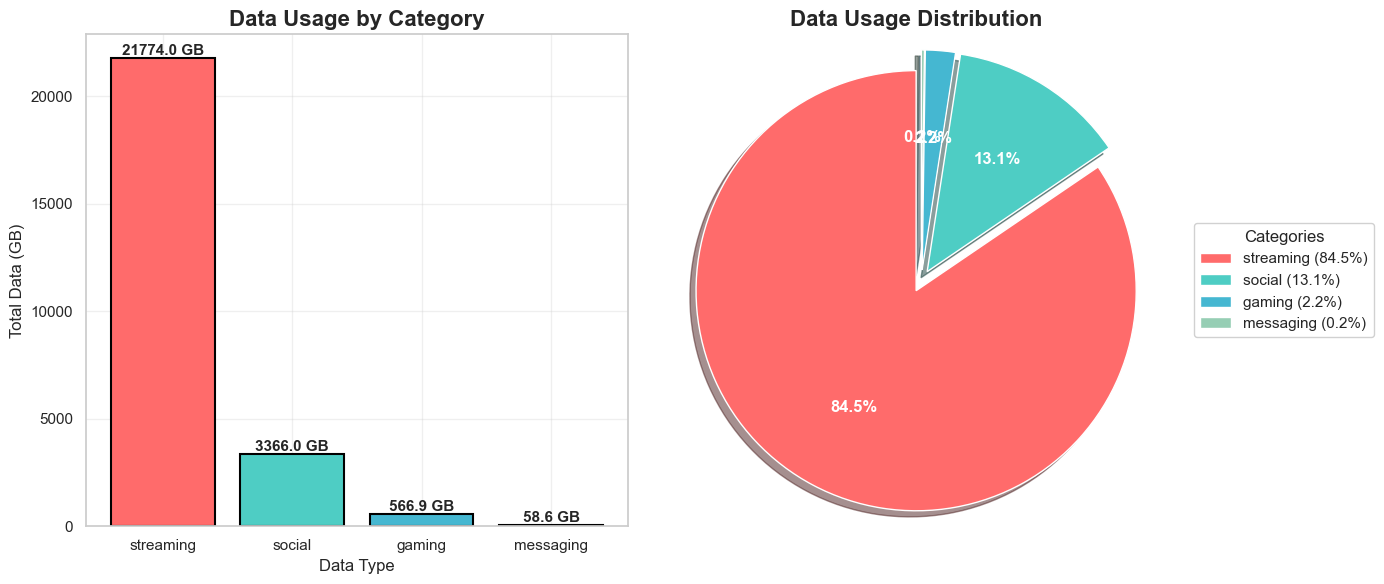

In [32]:


# Calculate totals for each category
totals = {
    'streaming': train_data['streaming_data_gb'].sum(),
    'social': train_data['social_data_gb'].sum(),
    'messaging': train_data['messaging_data_gb'].sum(),
    'gaming': train_data['gaming_data_gb'].sum()
}

result_df = pd.DataFrame(list(totals.items()), columns=['data_type', 'total_data'])
result_df['percentage'] = round(100 * result_df['total_data'] / result_df['total_data'].sum(), 2)
result_df['total_data'] = round(result_df['total_data'], 2)
result_df = result_df.sort_values('total_data', ascending=False)

# Print summary
print(result_df)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Colors
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

# 1. Bar Plot
bars = ax1.bar(result_df['data_type'], result_df['total_data'], color=colors, edgecolor='black', linewidth=1.5)
ax1.set_title('Data Usage by Category', fontsize=16, fontweight='bold')
ax1.set_xlabel('Data Type', fontsize=12)
ax1.set_ylabel('Total Data (GB)', fontsize=12)
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars (only values, no percentages)
for bar, value in zip(bars, result_df['total_data']):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.1f} GB',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# 2. Pie Chart with legend (avoids label overlap)
# Create custom labels with percentage for legend
labels = [f'{row["data_type"]} ({row["percentage"]:.1f}%)' 
          for _, row in result_df.iterrows()]

wedges, texts, autotexts = ax2.pie(result_df['total_data'], 
                                    labels=None,  # No direct labels
                                    autopct='%1.1f%%',
                                    colors=colors,
                                    startangle=90,
                                    explode=[0.05]*len(result_df),
                                    shadow=True,
                                    textprops={'color': 'white', 'fontweight': 'bold', 'fontsize': 12})

ax2.set_title('Data Usage Distribution', fontsize=16, fontweight='bold')

# Add legend
ax2.legend(wedges, labels, 
           title="Categories",
           loc="center left",
           bbox_to_anchor=(1, 0, 0.5, 1),
           fontsize=11,
           title_fontsize=12)

# Ensure pie is circular
ax2.axis('equal')

plt.tight_layout()
plt.show()

In [40]:


# Calculate total usage per user
train_data['total_usage_gb'] = (train_data['streaming_data_gb'] + 
                                 train_data['social_data_gb'] + 
                                 train_data['messaging_data_gb'] + 
                                 train_data['gaming_data_gb'])

# 1. Correlation between activities
print("=" * 60)
print("CORRELATION BETWEEN ACTIVITIES")
print("=" * 60)
correlation_matrix = train_data[['streaming_data_gb', 'social_data_gb', 
                                  'messaging_data_gb', 'gaming_data_gb']].corr()
print(correlation_matrix.round(3))
print("\n")

# 2. Average usage for different combinations
print("=" * 60)
print("AVERAGE USAGE BY ACTIVITY COMBINATION")
print("=" * 60)

#  pair combinations
combinations = {
    'Streaming + Social': train_data['streaming_data_gb'] + train_data['social_data_gb'],
    'Streaming + Messaging': train_data['streaming_data_gb'] + train_data['messaging_data_gb'],
    'Streaming + Gaming': train_data['streaming_data_gb'] + train_data['gaming_data_gb'],
    'Social + Messaging': train_data['social_data_gb'] + train_data['messaging_data_gb'],
    'Social + Gaming': train_data['social_data_gb'] + train_data['gaming_data_gb'],
    'Messaging + Gaming': train_data['messaging_data_gb'] + train_data['gaming_data_gb'],
    'Streaming + Social + Messaging': train_data['streaming_data_gb'] + train_data['social_data_gb'] + train_data['messaging_data_gb'],
    'Streaming + Social + Gaming': train_data['streaming_data_gb'] + train_data['social_data_gb'] + train_data['gaming_data_gb'],
    'Streaming + Messaging + Gaming': train_data['streaming_data_gb'] + train_data['messaging_data_gb'] + train_data['gaming_data_gb'],
    'Social + Messaging + Gaming': train_data['social_data_gb'] + train_data['messaging_data_gb'] + train_data['gaming_data_gb'],
    'All Activities': train_data['total_usage_gb']
}

# Calculate average consumption for each combination
combination_avg = {name: values.mean() for name, values in combinations.items()}
combination_df = pd.DataFrame(list(combination_avg.items()), 
                              columns=['Combination', 'Avg_Usage_GB'])
combination_df['Avg_Usage_GB'] = combination_df['Avg_Usage_GB'].round(2)
combination_df = combination_df.sort_values('Avg_Usage_GB', ascending=False)

print(combination_df.to_string(index=False))
print("\n")

# 3. Top 5 highest consumption combinations
print("=" * 60)
print("TOP 5 COMBINATIONS WITH HIGHEST AVERAGE USAGE")
print("=" * 60)
top_5 = combination_df.head(5)
for idx, row in top_5.iterrows():
    print(f"{row['Combination']}: {row['Avg_Usage_GB']} GB")
print("\n")

# 4. Individual activity averages
print("=" * 60)
print("AVERAGE USAGE BY INDIVIDUAL ACTIVITY")
print("=" * 60)
individual_avg = {
    'Streaming': train_data['streaming_data_gb'].mean(),
    'Social': train_data['social_data_gb'].mean(),
    'Messaging': train_data['messaging_data_gb'].mean(),
    'Gaming': train_data['gaming_data_gb'].mean()
}
individual_df = pd.DataFrame(list(individual_avg.items()), 
                             columns=['Activity', 'Avg_Usage_GB'])
individual_df['Avg_Usage_GB'] = individual_df['Avg_Usage_GB'].round(2)
individual_df = individual_df.sort_values('Avg_Usage_GB', ascending=False)
print(individual_df.to_string(index=False))
print("\n")

# 5. Most common primary activity per user
print("=" * 60)
print("MOST COMMON PRIMARY ACTIVITY (HIGHEST USAGE PER USER)")
print("=" * 60)
train_data['top_activity'] = train_data[['streaming_data_gb', 'social_data_gb', 
                                          'messaging_data_gb', 'gaming_data_gb']].idxmax(axis=1)
train_data['top_activity'] = train_data['top_activity'].str.replace('_data_gb', '')
top_activity_counts = train_data['top_activity'].value_counts()
for activity, count in top_activity_counts.items():
    percentage = (count / len(train_data)) * 100
    print(f"{activity}: {count} users ({percentage:.1f}%)")
print("\n")

# 6. Total consumption by combination type (sum across all users)
print("=" * 60)
print("TOTAL CONSUMPTION BY ACTIVITY TYPE (ALL USERS)")
print("=" * 60)
total_by_activity = {
    'Streaming': train_data['streaming_data_gb'].sum(),
    'Social': train_data['social_data_gb'].sum(),
    'Messaging': train_data['messaging_data_gb'].sum(),
    'Gaming': train_data['gaming_data_gb'].sum()
}
total_df = pd.DataFrame(list(total_by_activity.items()), 
                        columns=['Activity', 'Total_Usage_GB'])
total_df['Total_Usage_GB'] = total_df['Total_Usage_GB'].round(2)
total_df['Percentage'] = round(100 * total_df['Total_Usage_GB'] / total_df['Total_Usage_GB'].sum(), 2)
total_df = total_df.sort_values('Total_Usage_GB', ascending=False)
print(total_df.to_string(index=False))
print("\n")

# 7. Find the combination with highest total consumption
print("=" * 60)
print("KEY INSIGHTS")
print("=" * 60)
highest_combo = combination_df.iloc[0]
print(f" Highest average consumption combination: {highest_combo['Combination']}")
print(f"   Average: {highest_combo['Avg_Usage_GB']} GB")

highest_individual = individual_df.iloc[0]
print(f" Highest individual activity: {highest_individual['Activity']}")
print(f"   Average: {highest_individual['Avg_Usage_GB']} GB")

most_common = top_activity_counts.index[0]
print(f"👤 Most common primary activity: {most_common}")
print(f"   {top_activity_counts[most_common]} users ({top_activity_counts[most_common]/len(train_data)*100:.1f}%)")

# Find highest correlated pair
corr_matrix = train_data[['streaming_data_gb', 'social_data_gb', 
                           'messaging_data_gb', 'gaming_data_gb']].corr()
corr_unstacked = corr_matrix.unstack()
corr_unstacked = corr_unstacked[corr_unstacked < 1]
top_pair = corr_unstacked.idxmax()
print(f" Strongest correlation: {top_pair[0].replace('_data_gb', '')} & {top_pair[1].replace('_data_gb', '')}")
print(f"   Correlation: {corr_unstacked.max():.3f}")

CORRELATION BETWEEN ACTIVITIES
                   streaming_data_gb  social_data_gb  messaging_data_gb  gaming_data_gb
streaming_data_gb               1.00            0.40               0.26            0.21
social_data_gb                  0.40            1.00               0.27            0.23
messaging_data_gb               0.26            0.27               1.00            0.16
gaming_data_gb                  0.21            0.23               0.16            1.00


AVERAGE USAGE BY ACTIVITY COMBINATION
                   Combination  Avg_Usage_GB
                All Activities          3.22
   Streaming + Social + Gaming          3.21
Streaming + Social + Messaging          3.15
            Streaming + Social          3.14
Streaming + Messaging + Gaming          2.80
            Streaming + Gaming          2.79
         Streaming + Messaging          2.73
   Social + Messaging + Gaming          0.50
               Social + Gaming          0.49
            Social + Messaging         

# Time-Based Patterns (Network Optimization)

Peak Hours Analysis:
   is_peak_hour_user  total_data_gb        time_category
0                  0           2.98       Non-Peak Hours
1                  1           3.79  Peak Hours (6-9 PM)


Weekend vs Weekday Analysis:
   is_weekend  total_data_gb day_category
0           0           3.05      Weekday
1           1           3.66      Weekend




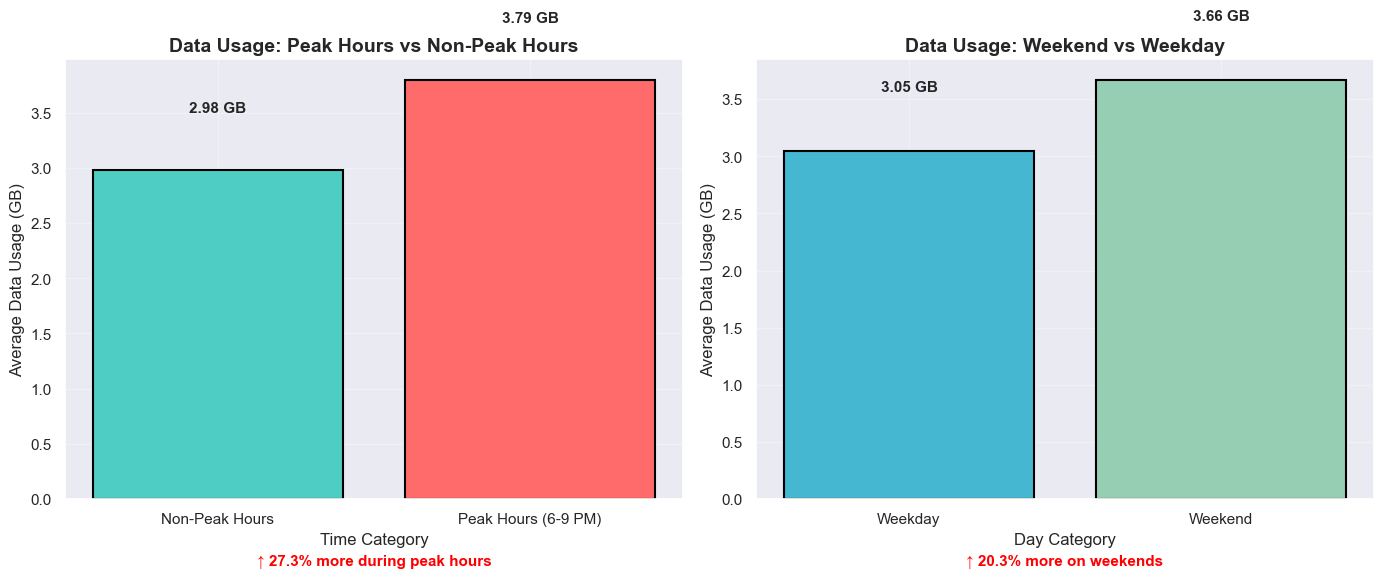

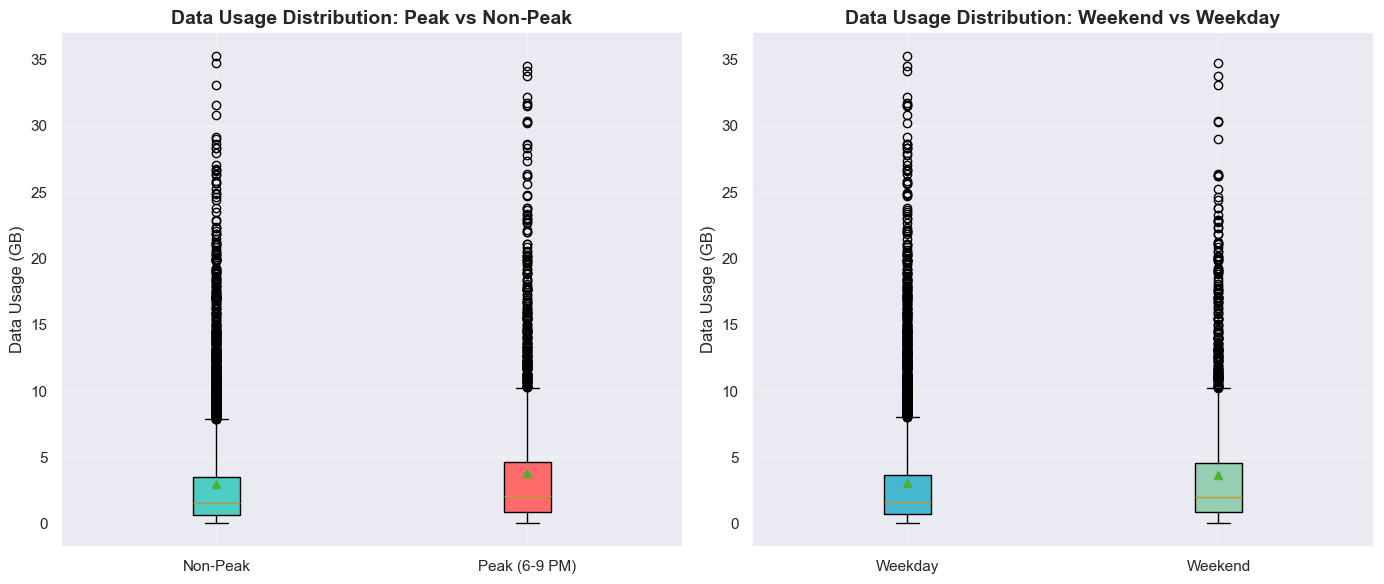

STATISTICAL SUMMARY

Peak Hours Analysis:
               mean  median  std  min   max
Non-Peak       2.98    1.59 3.90 0.02 35.28
Peak (6-9 PM)  3.79    2.09 4.76 0.02 34.47

Difference: 27.26% more during peak hours

Weekend vs Weekday Analysis:
         mean  median  std  min   max
Weekday  3.05    1.61 4.05 0.02 35.28
Weekend  3.66    2.01 4.50 0.03 34.72

Difference: 20.27% more on weekends


In [50]:

# Set style
sns.set_style("darkgrid")
plt.rcParams['font.size'] = 12


# 1. Peak Hours Analysis
data_peak = train_data.groupby('is_peak_hour_user')['total_data_gb'].mean().reset_index()
# Map values for better labels
data_peak['time_category'] = data_peak['is_peak_hour_user'].map({0: 'Non-Peak Hours', 1: 'Peak Hours (6-9 PM)'})

print("Peak Hours Analysis:")
print(data_peak)
print("\n")

# 2. Weekend vs Weekday Analysis
data_weekend = train_data.groupby('is_weekend')['total_data_gb'].mean().reset_index()
# Map values for better labels
data_weekend['day_category'] = data_weekend['is_weekend'].map({0: 'Weekday', 1: 'Weekend'})

print("Weekend vs Weekday Analysis:")
print(data_weekend)
print("\n")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Colors
colors_peak = ['#4ECDC4', '#FF6B6B']
colors_weekend = ['#45B7D1', '#96CEB4']

# 1. Bar Plot - Peak vs Non-Peak Hours
bars1 = ax1.bar(data_peak['time_category'], data_peak['total_data_gb'], 
                color=colors_peak, edgecolor='black', linewidth=1.5)
ax1.set_title('Data Usage: Peak Hours vs Non-Peak Hours', fontsize=14, fontweight='bold')
ax1.set_xlabel('Time Category', fontsize=12)
ax1.set_ylabel('Average Data Usage (GB)', fontsize=12)
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, value in zip(bars1, data_peak['total_data_gb']):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{value:.2f} GB', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add percentage difference
peak_val = data_peak[data_peak['is_peak_hour_user'] == 1]['total_data_gb'].values[0]
non_peak_val = data_peak[data_peak['is_peak_hour_user'] == 0]['total_data_gb'].values[0]
diff_percent = ((peak_val - non_peak_val) / non_peak_val) * 100
ax1.text(0.5, -0.15, f'↑ {diff_percent:.1f}% more during peak hours', 
         transform=ax1.transAxes, ha='center', fontsize=11, 
         fontweight='bold', color='red')

# 2. Bar Plot - Weekend vs Weekday
bars2 = ax2.bar(data_weekend['day_category'], data_weekend['total_data_gb'], 
                color=colors_weekend, edgecolor='black', linewidth=1.5)
ax2.set_title('Data Usage: Weekend vs Weekday', fontsize=14, fontweight='bold')
ax2.set_xlabel('Day Category', fontsize=12)
ax2.set_ylabel('Average Data Usage (GB)', fontsize=12)
ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, value in zip(bars2, data_weekend['total_data_gb']):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{value:.2f} GB', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add percentage difference
weekend_val = data_weekend[data_weekend['is_weekend'] == 1]['total_data_gb'].values[0]
weekday_val = data_weekend[data_weekend['is_weekend'] == 0]['total_data_gb'].values[0]
diff_percent_weekend = ((weekend_val - weekday_val) / weekday_val) * 100
ax2.text(0.5, -0.15, f'↑ {diff_percent_weekend:.1f}% more on weekends', 
         transform=ax2.transAxes, ha='center', fontsize=11, 
         fontweight='bold', color='red')

plt.tight_layout()
plt.show()


# Box plot for more detailed distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Box plot - Peak vs Non-Peak
peak_data = [train_data[train_data['is_peak_hour_user'] == 0]['total_data_gb'],
             train_data[train_data['is_peak_hour_user'] == 1]['total_data_gb']]
bp1 = ax1.boxplot(peak_data, labels=['Non-Peak', 'Peak (6-9 PM)'], 
                  patch_artist=True, showmeans=True)
bp1['boxes'][0].set_facecolor('#4ECDC4')
bp1['boxes'][1].set_facecolor('#FF6B6B')
ax1.set_title('Data Usage Distribution: Peak vs Non-Peak', fontsize=14, fontweight='bold')
ax1.set_ylabel('Data Usage (GB)', fontsize=12)
ax1.grid(axis='y', alpha=0.3)

# Box plot - Weekend vs Weekday
weekend_data = [train_data[train_data['is_weekend'] == 0]['total_data_gb'],
                train_data[train_data['is_weekend'] == 1]['total_data_gb']]
bp2 = ax2.boxplot(weekend_data, labels=['Weekday', 'Weekend'], 
                  patch_artist=True, showmeans=True)
bp2['boxes'][0].set_facecolor('#45B7D1')
bp2['boxes'][1].set_facecolor('#96CEB4')
ax2.set_title('Data Usage Distribution: Weekend vs Weekday', fontsize=14, fontweight='bold')
ax2.set_ylabel('Data Usage (GB)', fontsize=12)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical summary
print("=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)

print("\nPeak Hours Analysis:")
peak_stats = train_data.groupby('is_peak_hour_user')['total_data_gb'].agg(['mean', 'median', 'std', 'min', 'max'])
peak_stats.index = ['Non-Peak', 'Peak (6-9 PM)']
print(peak_stats.round(2))
print(f"\nDifference: {diff_percent:.2f}% more during peak hours")

print("\nWeekend vs Weekday Analysis:")
weekend_stats = train_data.groupby('is_weekend')['total_data_gb'].agg(['mean', 'median', 'std', 'min', 'max'])
weekend_stats.index = ['Weekday', 'Weekend']
print(weekend_stats.round(2))
print(f"\nDifference: {diff_percent_weekend:.2f}% more on weekends")



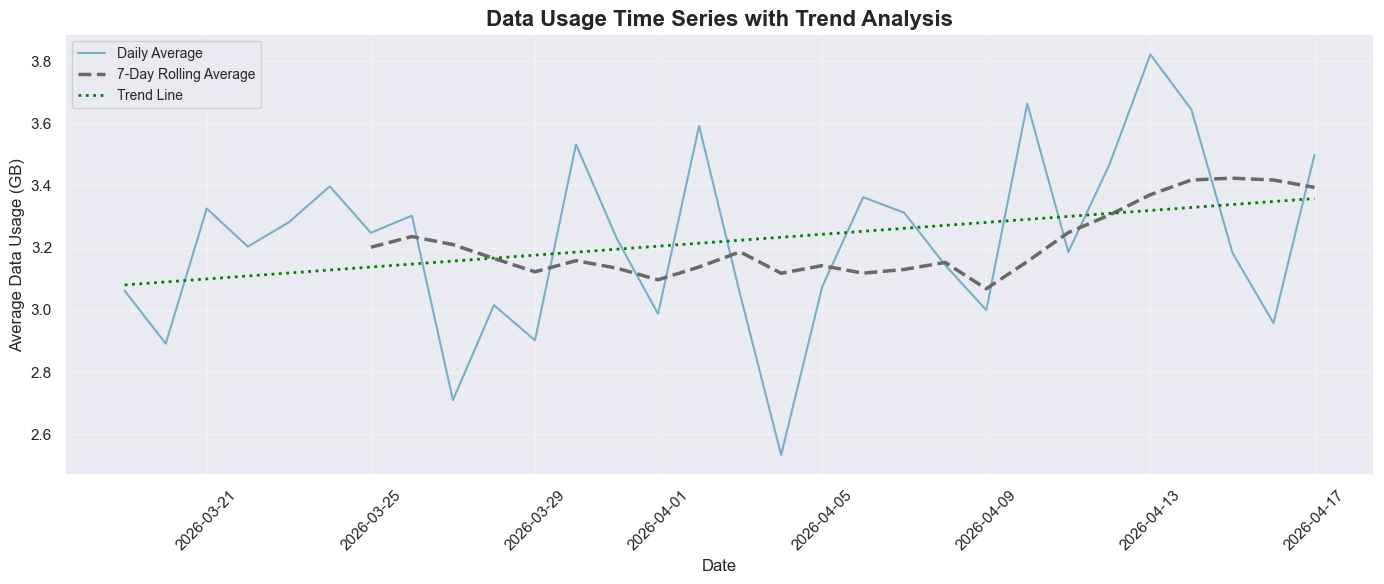

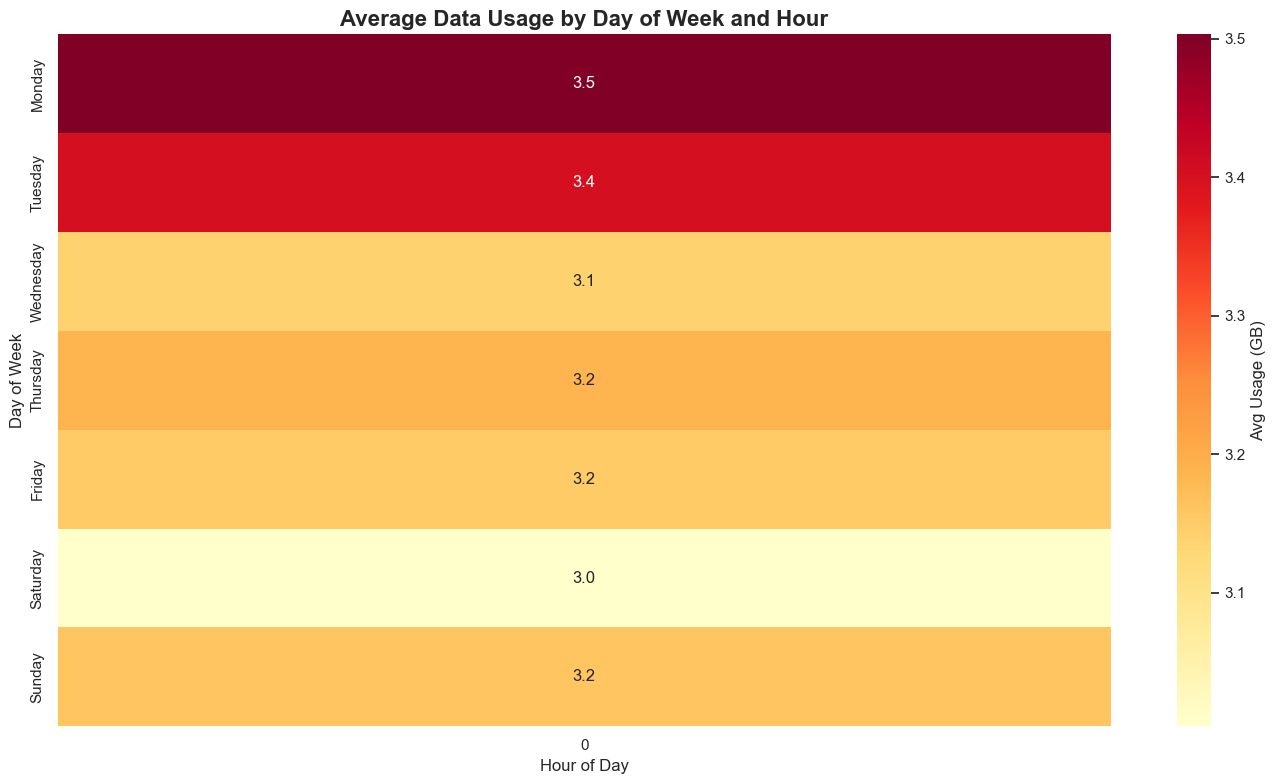

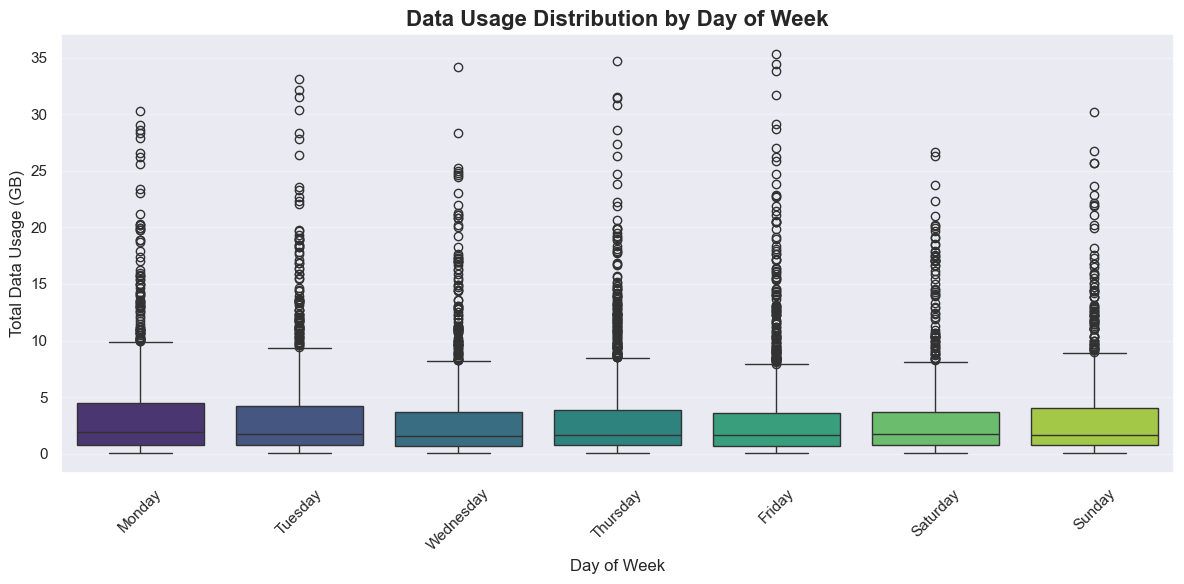

TIME SERIES STATISTICAL SUMMARY

Daily Usage Statistics:
count   30.00
mean     3.22
std      0.29
min      2.53
25%      3.02
50%      3.22
75%      3.39
max      3.82
Name: avg_usage_gb, dtype: float64

Weekly Usage Statistics:
count   5.00
mean    3.22
std     0.14
min     3.12
25%     3.12
50%     3.14
75%     3.30
max     3.42
Name: avg_usage_gb, dtype: float64

Monthly Usage Statistics:
count   2.00
mean    3.21
std     0.07
min     3.16
25%     3.19
50%     3.21
75%     3.24
max     3.26
Name: avg_usage_gb, dtype: float64

Overall Trend: increasing at 0.0096 GB per day

Highest usage day: 2026-04-13 (3.82 GB)
Lowest usage day: 2026-04-04 (2.53 GB)

Average Usage by Day of Week:
  Monday: 3.50 GB
  Tuesday: 3.40 GB
  Wednesday: 3.14 GB
  Thursday: 3.19 GB
  Friday: 3.15 GB
  Saturday: 3.00 GB
  Sunday: 3.16 GB

Peak usage hour: 0:00 (3.22 GB)


In [54]:
# 1. Daily Time Series - Average usage per day
daily_avg = train_data.groupby('measurement_date')['total_data_gb'].mean().reset_index()
daily_avg.columns = ['date', 'avg_usage_gb']

# 2. Daily Time Series - Total usage per day
daily_total = train_data.groupby('measurement_date')['total_data_gb'].sum().reset_index()
daily_total.columns = ['date', 'total_usage_gb']

# 3. Weekly aggregation
weekly_avg = train_data.groupby(pd.Grouper(key='measurement_date', freq='W'))['total_data_gb'].mean().reset_index()
weekly_avg.columns = ['week', 'avg_usage_gb']

# 4. Monthly aggregation
monthly_avg = train_data.groupby(pd.Grouper(key='measurement_date', freq='M'))['total_data_gb'].mean().reset_index()
monthly_avg.columns = ['month', 'avg_usage_gb']

# Time series with trend line
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(daily_avg['date'], daily_avg['avg_usage_gb'],
    color=TELECOM_COLOR, linewidth=1.5, alpha=0.6, label='Daily Average')

# Add rolling average (7-day)
daily_avg['rolling_7d'] = daily_avg['avg_usage_gb'].rolling(window=7).mean()
ax.plot(daily_avg['date'], daily_avg['rolling_7d'],
    color='dimgray', linewidth=2.5, label='7-Day Rolling Average', linestyle='--')

# Add trend line
z = np.polyfit(range(len(daily_avg)), daily_avg['avg_usage_gb'], 1)
p = np.poly1d(z)
ax.plot(daily_avg['date'], p(range(len(daily_avg))),
    color='green', linewidth=2, label='Trend Line', linestyle=':')

ax.set_title('Data Usage Time Series with Trend Analysis', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Average Data Usage (GB)', fontsize=12)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Heatmap by Day of Week and Hour (if hour data available)
if 'day_of_week' not in train_data.columns:
    train_data['day_of_week'] = train_data['measurement_date'].dt.day_name()
if 'hour' not in train_data.columns:
    train_data['hour'] = train_data['measurement_date'].dt.hour

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
hourly_pattern = train_data.groupby(['day_of_week', 'hour'])['total_data_gb'].mean().reset_index()
pivot_table = hourly_pattern.pivot(index='day_of_week', columns='hour', values='total_data_gb').reindex(day_order)

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_table, cmap='YlOrRd', annot=True, fmt='.1f', cbar_kws={'label': 'Avg Usage (GB)'})
plt.title('Average Data Usage by Day of Week and Hour', fontsize=16, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Day of Week', fontsize=12)
plt.tight_layout()
plt.show()

# Box plots by day of week
plt.figure(figsize=(12, 6))
sns.boxplot(data=train_data, x='day_of_week', y='total_data_gb', order=day_order, palette='viridis')
plt.title('Data Usage Distribution by Day of Week', fontsize=16, fontweight='bold')
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Total Data Usage (GB)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Statistical summary of time series
print("=" * 60)
print("TIME SERIES STATISTICAL SUMMARY")
print("=" * 60)

print("\nDaily Usage Statistics:")
print(daily_avg['avg_usage_gb'].describe().round(2))

print("\nWeekly Usage Statistics:")
print(weekly_avg['avg_usage_gb'].describe().round(2))

print("\nMonthly Usage Statistics:")
print(monthly_avg['avg_usage_gb'].describe().round(2))

# Detect trend
if len(daily_avg) > 1:
    slope = z[0]
    direction = "increasing" if slope > 0 else "decreasing"
    print(f"\nOverall Trend: {direction} at {abs(slope):.4f} GB per day")

# Best and worst days
best_day = daily_avg.loc[daily_avg['avg_usage_gb'].idxmax()]
worst_day = daily_avg.loc[daily_avg['avg_usage_gb'].idxmin()]
print(f"\nHighest usage day: {best_day['date'].strftime('%Y-%m-%d')} ({best_day['avg_usage_gb']:.2f} GB)")
print(f"Lowest usage day: {worst_day['date'].strftime('%Y-%m-%d')} ({worst_day['avg_usage_gb']:.2f} GB)")

# Day of week analysis
day_avg = train_data.groupby('day_of_week')['total_data_gb'].mean().reindex(day_order)
print("\nAverage Usage by Day of Week:")
for day, value in day_avg.items():
    print(f"  {day}: {value:.2f} GB")

# Peak hours analysis by hour
hour_avg = train_data.groupby('hour')['total_data_gb'].mean()
if not hour_avg.empty:
    peak_hour = hour_avg.idxmax()
    print(f"\nPeak usage hour: {peak_hour}:00 ({hour_avg.max():.2f} GB)")


# Customer Segmentation (Who Uses Data?)

Age Group Analysis:
  age_group  avg_data_gb  user_count  std_dev
0     18-24         3.99        1988     4.75
1     25-34         3.81        2450     4.64
2     35-44         3.07        1663     3.86
3     45-54         2.15        1129     2.86
4       55+         1.27         774     1.78


Device Type Analysis:
          device_type  avg_data_gb  user_count  std_dev
0           5G_Device         4.26        1564     4.83
1         Basic_Phone         1.03         828     1.56
2           Mid_Range         2.78        2778     3.71
3  Premium_Smartphone         3.73        2448     4.48
4              Tablet         3.58         386     4.40


Network Type Analysis:
  network_type  avg_data_gb  user_count  std_dev
0           3G         0.79        1214     0.87
1           4G         2.38        3551     2.53
2          4G+         3.96        1245     4.24
3           5G         5.73        1994     5.98


Plan Type Analysis (Lowest Usage):
            plan_type  avg_data_gb  u

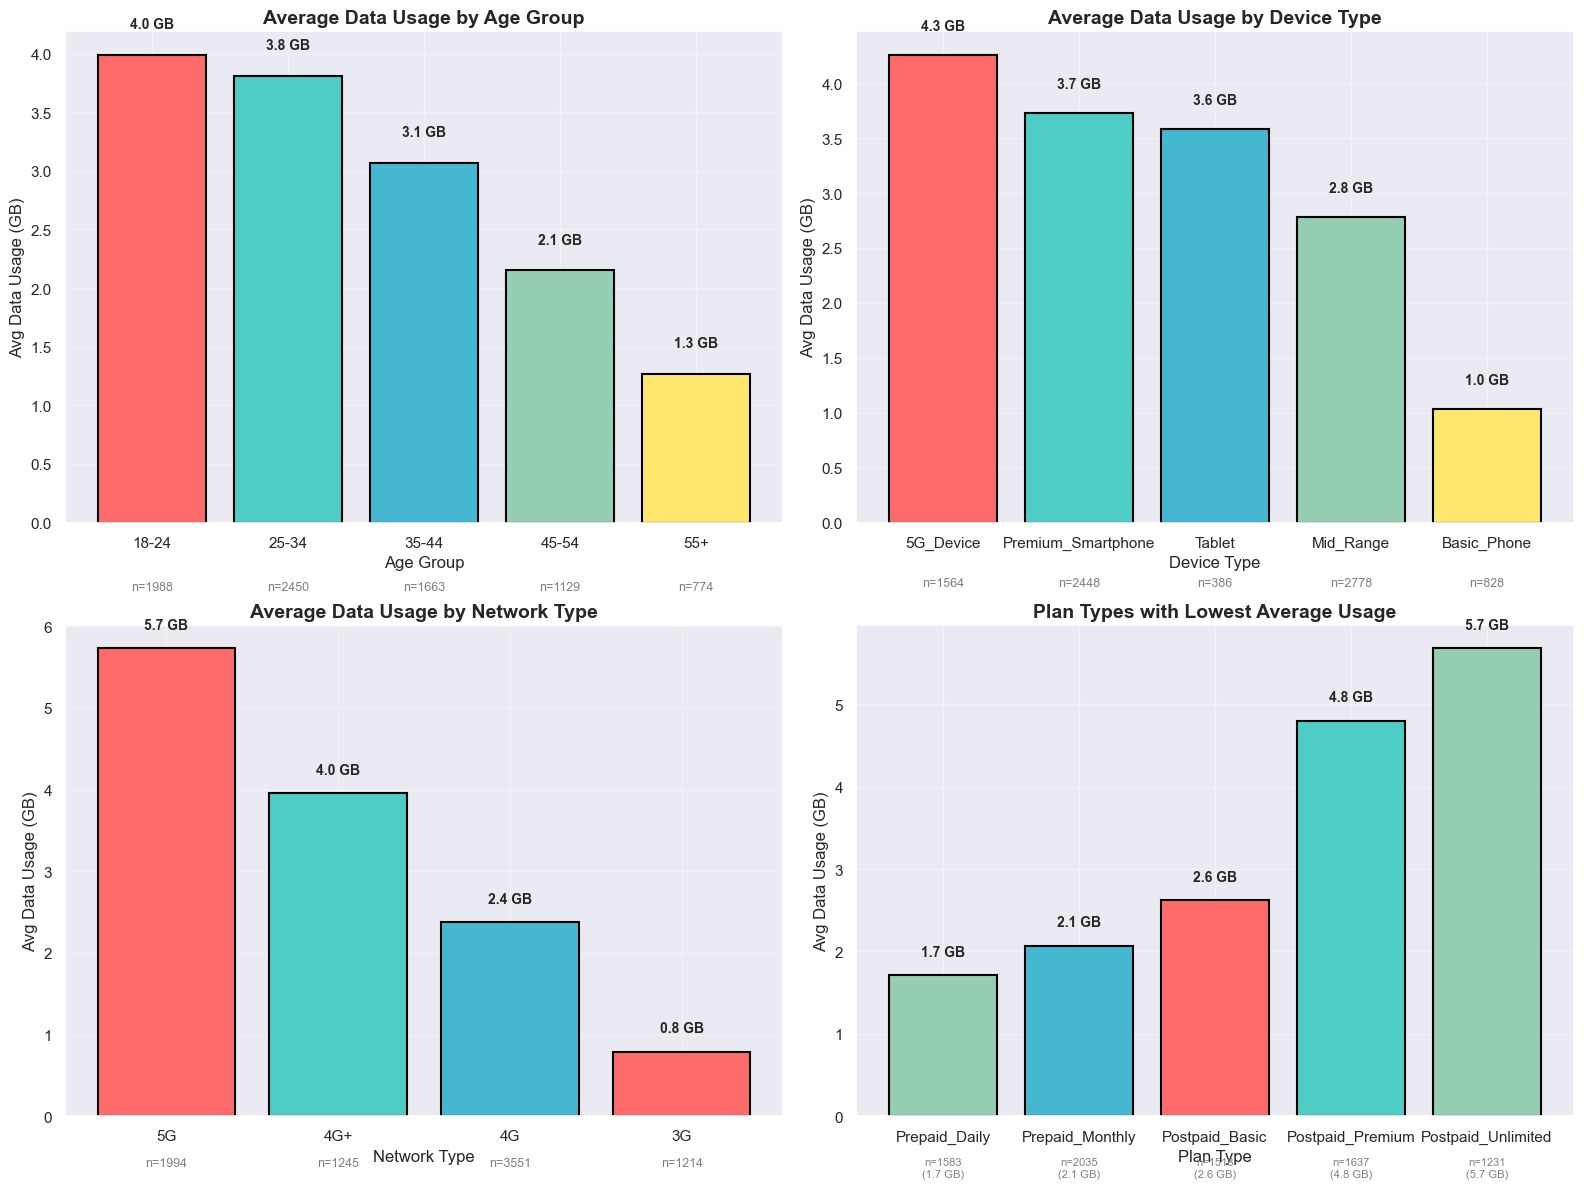

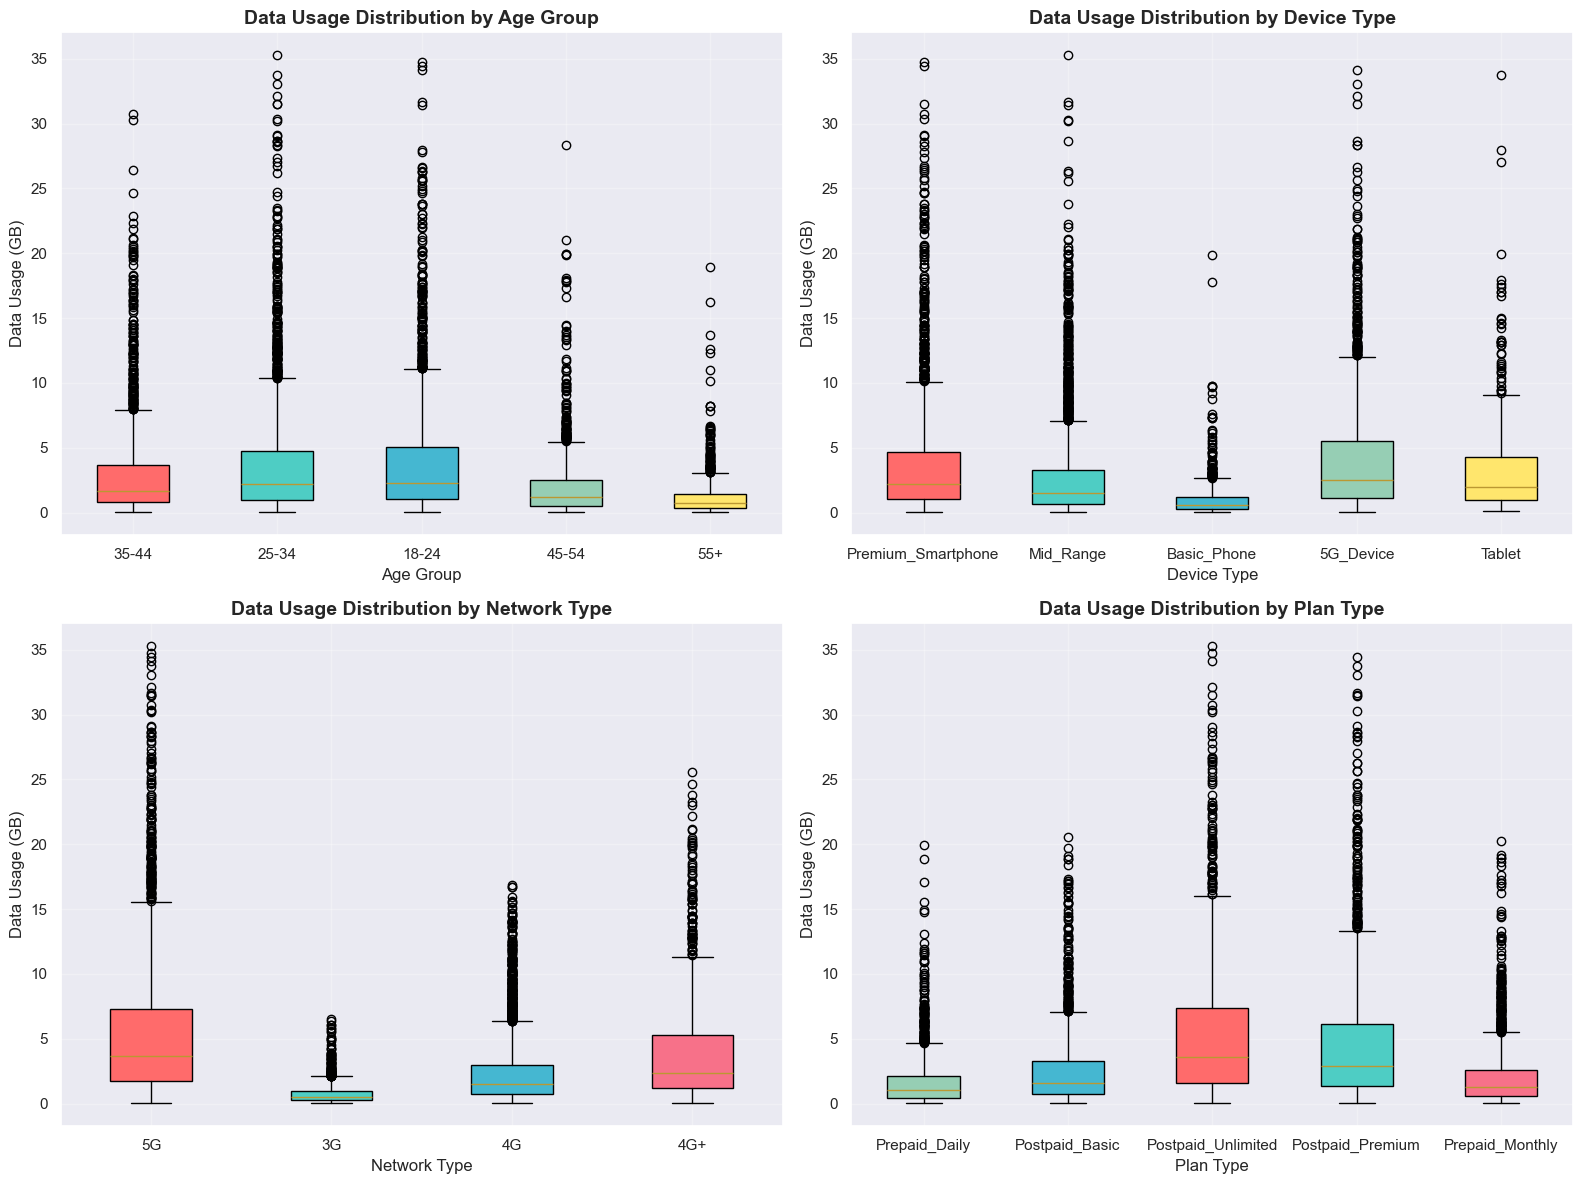

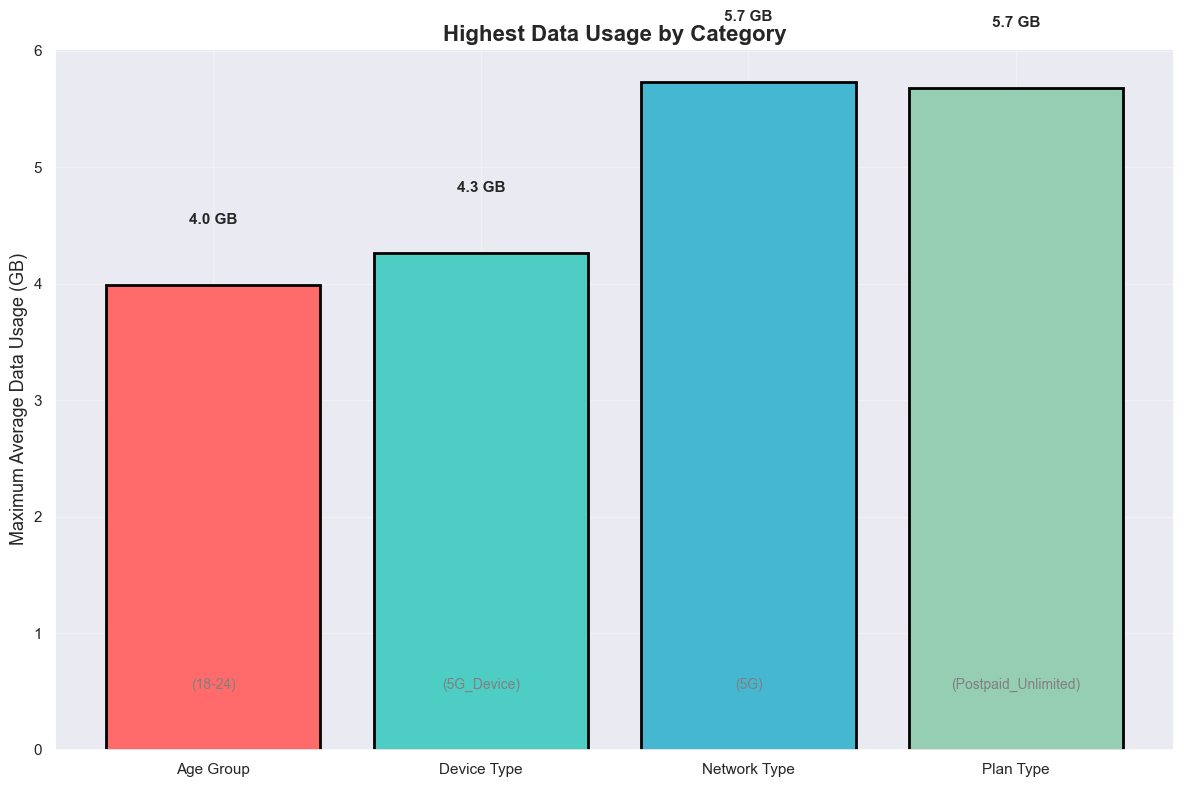

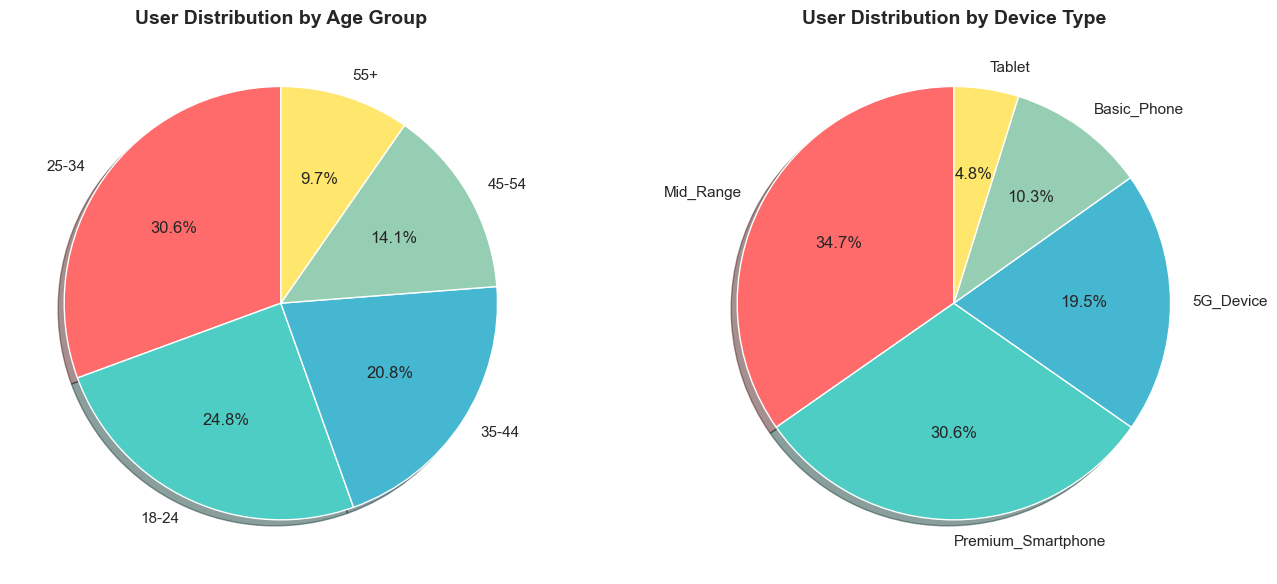


KEY INSIGHTS
 Highest data consuming age group: 18-24
   Average: 3.99 GB
   Number of users: 1988

 Highest data consuming device: 5G_Device
   Average: 4.26 GB
   Number of users: 1564

 Highest data consuming network: 5G
   Average: 5.73 GB
   Number of users: 1994

 5G users consume 141.1% more data than 4G/3G users
   5G: 5.73 GB vs Others: 2.38 GB

 Plan type with lowest usage: Prepaid_Daily
   Average: 1.71 GB
   Number of users: 1583

 Highest potential segment: Prepaid_Monthly
   Average usage: 2.07 GB
   Number of users: 2035
   Potential score: 983.09


In [57]:


# 1. Age Group Analysis
age_group_analysis = train_data.groupby('age_group')['total_data_gb'].agg(['mean', 'count', 'std']).reset_index()
age_group_analysis.columns = ['age_group', 'avg_data_gb', 'user_count', 'std_dev']
age_group_analysis['avg_data_gb'] = age_group_analysis['avg_data_gb'].round(2)

print("Age Group Analysis:")
print(age_group_analysis)
print("\n")

# 2. Device Type Analysis
device_analysis = train_data.groupby('device_type')['total_data_gb'].agg(['mean', 'count', 'std']).reset_index()
device_analysis.columns = ['device_type', 'avg_data_gb', 'user_count', 'std_dev']
device_analysis['avg_data_gb'] = device_analysis['avg_data_gb'].round(2)

print("Device Type Analysis:")
print(device_analysis)
print("\n")

# 3. Network Type Analysis
network_analysis = train_data.groupby('network_type')['total_data_gb'].agg(['mean', 'count', 'std']).reset_index()
network_analysis.columns = ['network_type', 'avg_data_gb', 'user_count', 'std_dev']
network_analysis['avg_data_gb'] = network_analysis['avg_data_gb'].round(2)

print("Network Type Analysis:")
print(network_analysis)
print("\n")

# 4. Plan Type Analysis (Lowest usage)
plan_analysis = train_data.groupby('plan_type')['total_data_gb'].agg(['mean', 'count']).reset_index()
plan_analysis.columns = ['plan_type', 'avg_data_gb', 'user_count']
plan_analysis['avg_data_gb'] = plan_analysis['avg_data_gb'].round(2)
plan_analysis = plan_analysis.sort_values('avg_data_gb', ascending=True)

print("Plan Type Analysis (Lowest Usage):")
print(plan_analysis)
print("\n")

# Create figure with 4 subplots (2x2)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Colors for different analyses
colors_age = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFE66D']
colors_device = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFE66D']
colors_network = ['#FF6B6B', '#4ECDC4', '#45B7D1']
colors_plan = ['#96CEB4', '#45B7D1', '#FF6B6B', '#4ECDC4']

# 1. Age Group - Average Data Usage
ax1 = axes[0, 0]
age_sorted = age_group_analysis.sort_values('avg_data_gb', ascending=False)
bars1 = ax1.bar(age_sorted['age_group'], age_sorted['avg_data_gb'], 
                color=colors_age[:len(age_sorted)], edgecolor='black', linewidth=1.5)
ax1.set_title('Average Data Usage by Age Group', fontsize=14, fontweight='bold')
ax1.set_xlabel('Age Group', fontsize=12)
ax1.set_ylabel('Avg Data Usage (GB)', fontsize=12)
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for bar, value in zip(bars1, age_sorted['avg_data_gb']):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.2,
             f'{value:.1f} GB', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add user count as secondary info
for i, (bar, count) in enumerate(zip(bars1, age_sorted['user_count'])):
    ax1.text(bar.get_x() + bar.get_width()/2., -0.5,
             f'n={count}', ha='center', va='top', fontsize=9, color='gray')

# 2. Device Type - Average Data Usage
ax2 = axes[0, 1]
device_sorted = device_analysis.sort_values('avg_data_gb', ascending=False)
bars2 = ax2.bar(device_sorted['device_type'], device_sorted['avg_data_gb'], 
                color=colors_device[:len(device_sorted)], edgecolor='black', linewidth=1.5)
ax2.set_title('Average Data Usage by Device Type', fontsize=14, fontweight='bold')
ax2.set_xlabel('Device Type', fontsize=12)
ax2.set_ylabel('Avg Data Usage (GB)', fontsize=12)
ax2.grid(axis='y', alpha=0.3)

for bar, value in zip(bars2, device_sorted['avg_data_gb']):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.2,
             f'{value:.1f} GB', ha='center', va='bottom', fontsize=10, fontweight='bold')

for i, (bar, count) in enumerate(zip(bars2, device_sorted['user_count'])):
    ax2.text(bar.get_x() + bar.get_width()/2., -0.5,
             f'n={count}', ha='center', va='top', fontsize=9, color='gray')

# 3. Network Type - Average Data Usage
ax3 = axes[1, 0]
network_sorted = network_analysis.sort_values('avg_data_gb', ascending=False)
bars3 = ax3.bar(network_sorted['network_type'], network_sorted['avg_data_gb'], 
                color=colors_network[:len(network_sorted)], edgecolor='black', linewidth=1.5)
ax3.set_title('Average Data Usage by Network Type', fontsize=14, fontweight='bold')
ax3.set_xlabel('Network Type', fontsize=12)
ax3.set_ylabel('Avg Data Usage (GB)', fontsize=12)
ax3.grid(axis='y', alpha=0.3)

for bar, value in zip(bars3, network_sorted['avg_data_gb']):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.2,
             f'{value:.1f} GB', ha='center', va='bottom', fontsize=10, fontweight='bold')

for i, (bar, count) in enumerate(zip(bars3, network_sorted['user_count'])):
    ax3.text(bar.get_x() + bar.get_width()/2., -0.5,
             f'n={count}', ha='center', va='top', fontsize=9, color='gray')

# 4. Plan Type - Lowest Usage (ascending)
ax4 = axes[1, 1]
bars4 = ax4.bar(plan_analysis['plan_type'], plan_analysis['avg_data_gb'], 
                color=colors_plan[:len(plan_analysis)], edgecolor='black', linewidth=1.5)
ax4.set_title('Plan Types with Lowest Average Usage', fontsize=14, fontweight='bold')
ax4.set_xlabel('Plan Type', fontsize=12)
ax4.set_ylabel('Avg Data Usage (GB)', fontsize=12)
ax4.grid(axis='y', alpha=0.3)

# Color bars based on usage (darker = lower usage)
for bar, value in zip(bars4, plan_analysis['avg_data_gb']):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.2,
             f'{value:.1f} GB', ha='center', va='bottom', fontsize=10, fontweight='bold')

for i, (bar, count, usage) in enumerate(zip(bars4, plan_analysis['user_count'], plan_analysis['avg_data_gb'])):
    ax4.text(bar.get_x() + bar.get_width()/2., -0.5,
             f'n={count}\n({usage:.1f} GB)', ha='center', va='top', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

# Additional visualizations

# 1. Box plots for each category
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Age Group Box Plot
ax1 = axes[0, 0]
age_groups = train_data['age_group'].unique()
age_data = [train_data[train_data['age_group'] == age]['total_data_gb'] for age in age_groups]
bp1 = ax1.boxplot(age_data, labels=age_groups, patch_artist=True)
for patch, color in zip(bp1['boxes'], colors_age[:len(age_groups)]):
    patch.set_facecolor(color)
ax1.set_title('Data Usage Distribution by Age Group', fontsize=14, fontweight='bold')
ax1.set_xlabel('Age Group', fontsize=12)
ax1.set_ylabel('Data Usage (GB)', fontsize=12)
ax1.grid(axis='y', alpha=0.3)

# Device Type Box Plot
ax2 = axes[0, 1]
devices = train_data['device_type'].unique()
device_data = [train_data[train_data['device_type'] == device]['total_data_gb'] for device in devices]
bp2 = ax2.boxplot(device_data, labels=devices, patch_artist=True)
for patch, color in zip(bp2['boxes'], colors_device[:len(devices)]):
    patch.set_facecolor(color)
ax2.set_title('Data Usage Distribution by Device Type', fontsize=14, fontweight='bold')
ax2.set_xlabel('Device Type', fontsize=12)
ax2.set_ylabel('Data Usage (GB)', fontsize=12)
ax2.grid(axis='y', alpha=0.3)

# Network Type Box Plot
ax3 = axes[1, 0]
networks = train_data['network_type'].unique()
network_data = [train_data[train_data['network_type'] == network]['total_data_gb'] for network in networks]
bp3 = ax3.boxplot(network_data, labels=networks, patch_artist=True)
for patch, color in zip(bp3['boxes'], colors_network[:len(networks)]):
    patch.set_facecolor(color)
ax3.set_title('Data Usage Distribution by Network Type', fontsize=14, fontweight='bold')
ax3.set_xlabel('Network Type', fontsize=12)
ax3.set_ylabel('Data Usage (GB)', fontsize=12)
ax3.grid(axis='y', alpha=0.3)

# Plan Type Box Plot
ax4 = axes[1, 1]
plans = train_data['plan_type'].unique()
plan_data = [train_data[train_data['plan_type'] == plan]['total_data_gb'] for plan in plans]
bp4 = ax4.boxplot(plan_data, labels=plans, patch_artist=True)
for patch, color in zip(bp4['boxes'], colors_plan[:len(plans)]):
    patch.set_facecolor(color)
ax4.set_title('Data Usage Distribution by Plan Type', fontsize=14, fontweight='bold')
ax4.set_xlabel('Plan Type', fontsize=12)
ax4.set_ylabel('Data Usage (GB)', fontsize=12)
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Combined visualization with subplots showing relationships
fig, ax = plt.subplots(figsize=(12, 8))

# Create a grouped bar chart showing all categories
categories = ['Age Group', 'Device Type', 'Network Type', 'Plan Type']
values = []

# Get the highest usage for each category
values.append(age_group_analysis.loc[age_group_analysis['avg_data_gb'].idxmax(), 'avg_data_gb'])
values.append(device_analysis.loc[device_analysis['avg_data_gb'].idxmax(), 'avg_data_gb'])
values.append(network_analysis.loc[network_analysis['avg_data_gb'].idxmax(), 'avg_data_gb'])
values.append(plan_analysis.loc[plan_analysis['avg_data_gb'].idxmax(), 'avg_data_gb'])

bars = ax.bar(categories, values, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'], 
              edgecolor='black', linewidth=2)
ax.set_title('Highest Data Usage by Category', fontsize=16, fontweight='bold')
ax.set_ylabel('Maximum Average Data Usage (GB)', fontsize=13)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bar, value in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{value:.1f} GB', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add subtext with category details
details = [
    f"({age_group_analysis.loc[age_group_analysis['avg_data_gb'].idxmax(), 'age_group']})",
    f"({device_analysis.loc[device_analysis['avg_data_gb'].idxmax(), 'device_type']})",
    f"({network_analysis.loc[network_analysis['avg_data_gb'].idxmax(), 'network_type']})",
    f"({plan_analysis.loc[plan_analysis['avg_data_gb'].idxmax(), 'plan_type']})"
]

for bar, detail in zip(bars, details):
    ax.text(bar.get_x() + bar.get_width()/2., 0.5,
            detail, ha='center', va='bottom', fontsize=10, color='gray')

plt.tight_layout()
plt.show()

# 3. Percentage contribution pie charts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart - Age Group distribution of users
ax1 = axes[0]
age_counts = train_data['age_group'].value_counts()
ax1.pie(age_counts.values, labels=age_counts.index, autopct='%1.1f%%', 
        colors=colors_age[:len(age_counts)], startangle=90, shadow=True)
ax1.set_title('User Distribution by Age Group', fontsize=14, fontweight='bold')

# Pie chart - Device Type distribution of users
ax2 = axes[1]
device_counts = train_data['device_type'].value_counts()
ax2.pie(device_counts.values, labels=device_counts.index, autopct='%1.1f%%', 
        colors=colors_device[:len(device_counts)], startangle=90, shadow=True)
ax2.set_title('User Distribution by Device Type', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary insights
print("\n" + "=" * 60)
print("KEY INSIGHTS")
print("=" * 60)

# Age Group
top_age = age_group_analysis.loc[age_group_analysis['avg_data_gb'].idxmax()]
print(f" Highest data consuming age group: {top_age['age_group']}")
print(f"   Average: {top_age['avg_data_gb']:.2f} GB")
print(f"   Number of users: {top_age['user_count']}")

# Device
top_device = device_analysis.loc[device_analysis['avg_data_gb'].idxmax()]
print(f"\n Highest data consuming device: {top_device['device_type']}")
print(f"   Average: {top_device['avg_data_gb']:.2f} GB")
print(f"   Number of users: {top_device['user_count']}")

# Network
top_network = network_analysis.loc[network_analysis['avg_data_gb'].idxmax()]
print(f"\n Highest data consuming network: {top_network['network_type']}")
print(f"   Average: {top_network['avg_data_gb']:.2f} GB")
print(f"   Number of users: {top_network['user_count']}")

# 5G vs others
if '5G' in network_analysis['network_type'].values:
    avg_5g = network_analysis[network_analysis['network_type'] == '5G']['avg_data_gb'].values[0]
    avg_others = network_analysis[network_analysis['network_type'] != '5G']['avg_data_gb'].mean()
    diff_percent = ((avg_5g - avg_others) / avg_others) * 100
    print(f"\n 5G users consume {diff_percent:.1f}% more data than 4G/3G users")
    print(f"   5G: {avg_5g:.2f} GB vs Others: {avg_others:.2f} GB")

# Plan types with lowest usage
lowest_plan = plan_analysis.iloc[0]
print(f"\n Plan type with lowest usage: {lowest_plan['plan_type']}")
print(f"   Average: {lowest_plan['avg_data_gb']:.2f} GB")
print(f"   Number of users: {lowest_plan['user_count']}")

# Segment with highest potential (lowest usage but high user count)
plan_analysis['potential_score'] = plan_analysis['user_count'] / plan_analysis['avg_data_gb']
highest_potential = plan_analysis.loc[plan_analysis['potential_score'].idxmax()]
print(f"\n Highest potential segment: {highest_potential['plan_type']}")
print(f"   Average usage: {highest_potential['avg_data_gb']:.2f} GB")
print(f"   Number of users: {highest_potential['user_count']}")
print(f"   Potential score: {highest_potential['potential_score']:.2f}")